In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

aapl = pd.read_csv('../data/raw/AAPL.csv', parse_dates=['Date'], index_col='Date')
aapl.sort_index(inplace=True)
print(aapl.head())

               Close      High       Low      Open      Volume
Date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [12]:
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

# Compute indicators
aapl['SMA_20'] = SMAIndicator(close=aapl['Close'], window=20).sma_indicator()
aapl['EMA_20'] = EMAIndicator(close=aapl['Close'], window=20).ema_indicator()
aapl['RSI_14'] = RSIIndicator(close=aapl['Close'], window=14).rsi()
macd = MACD(close=aapl['Close'])
aapl['MACD'] = macd.macd()
aapl['MACD_signal'] = macd.macd_signal()
aapl['MACD_histogram'] = macd.macd_diff()

print("Columns after indicator addition:")
print(aapl.columns.tolist())

Columns after indicator addition:
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'EMA_20', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_histogram']


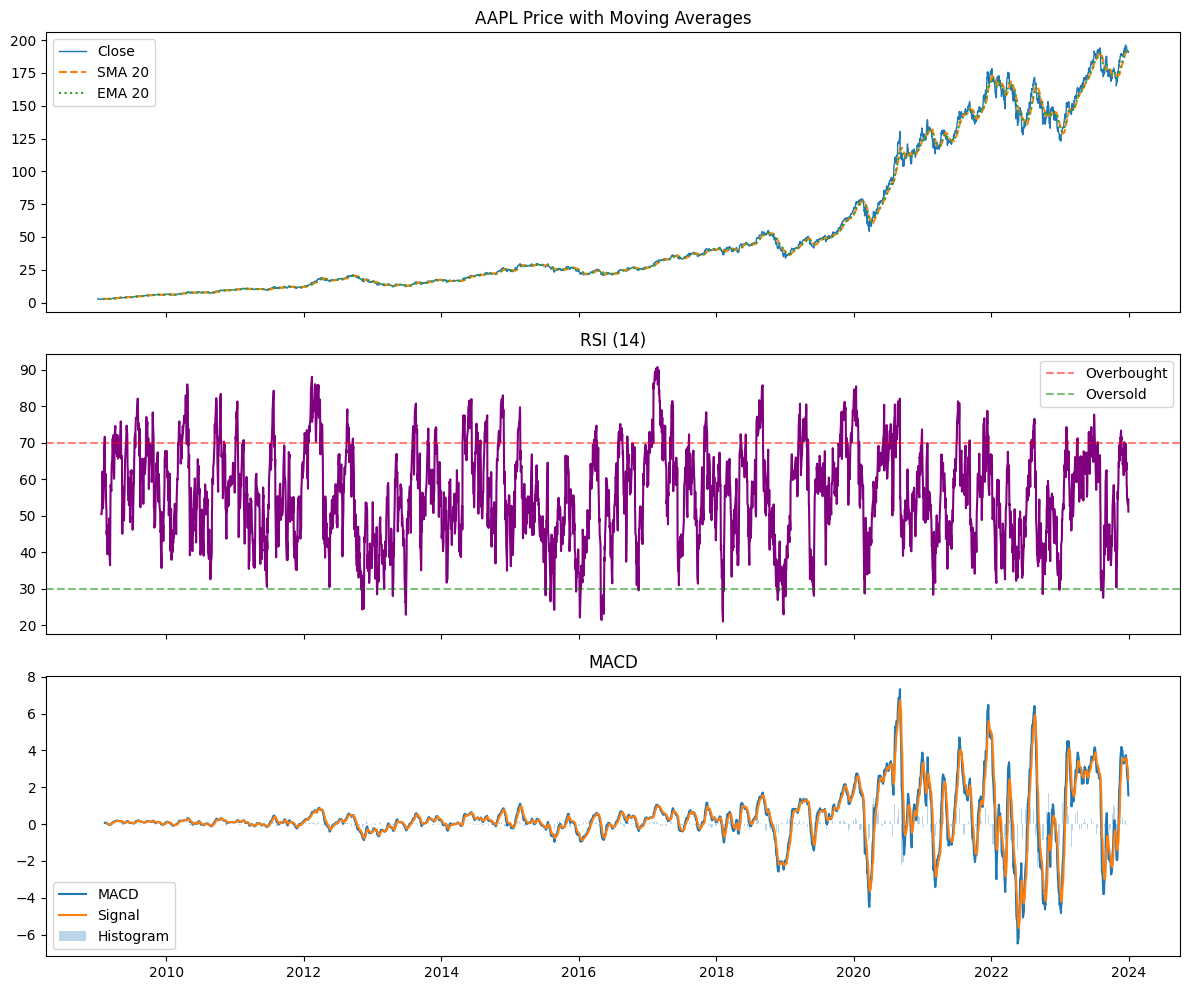

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Price and moving averages
ax1.plot(aapl.index, aapl['Close'], label='Close', linewidth=1)
if 'SMA_20' in aapl.columns:
    ax1.plot(aapl.index, aapl['SMA_20'], label='SMA 20', linestyle='--')
if 'EMA_20' in aapl.columns:
    ax1.plot(aapl.index, aapl['EMA_20'], label='EMA 20', linestyle=':')
ax1.legend()
ax1.set_title('AAPL Price with Moving Averages')

# RSI
if 'RSI_14' in aapl.columns:
    ax2.plot(aapl.index, aapl['RSI_14'], color='purple')
    ax2.axhline(70, linestyle='--', color='r', alpha=0.5, label='Overbought')
    ax2.axhline(30, linestyle='--', color='g', alpha=0.5, label='Oversold')
    ax2.legend()
ax2.set_title('RSI (14)')

# MACD
if 'MACD' in aapl.columns and 'MACD_signal' in aapl.columns:
    ax3.plot(aapl.index, aapl['MACD'], label='MACD')
    ax3.plot(aapl.index, aapl['MACD_signal'], label='Signal')
if 'MACD_histogram' in aapl.columns:
    ax3.bar(aapl.index, aapl['MACD_histogram'], label='Histogram', alpha=0.3)
ax3.legend()
ax3.set_title('MACD')

plt.tight_layout()
plt.show()